#  Project 03: Biomarker Identification from Gene Expression Data using Machine Learning (Classification Project)

## 👤 Author
Pritom Kundu
B Pharm Honors | University of Rajshahi, Bangladesh

## 📝 Project Overview
This project delves into the vital challenge of identifying robust **biomarkers** from intricate gene expression datasets, utilizing cutting-edge **machine learning classification** techniques. Our primary objective is to forge predictive models capable of *accurately discerning* between various biological states—such as healthy vs. disease, or distinct disease subtypes. By harnessing the power of high-throughput gene expression data, we aim to unearth specific genetic signatures that serve as **reliable indicators** for:
*   🔬 Disease diagnosis
*   📈 Prognosis assessment
*   💊 Guiding therapy response

Our methodology will encompass:
1.  **Rigorous Data Preprocessing:** Ensuring data quality and consistency.
2.  **Strategic Feature Selection:** Pinpointing the most informative genes.
3.  **Advanced Classification Algorithms:** Employing techniques like Support Vector Machines, Random Forests, and Neural Networks to construct robust predictive models.

Model performance will be meticulously evaluated using standard metrics, with a significant emphasis on **interpretability**. This allows us to elucidate the *biological relevance* of the identified biomarkers. This research holds profound implications for **precision medicine**, promising to:
*   Early detection enhancement
*   Treatment strategy optimization
*   Deepening our understanding of disease pathogenesis at a molecular level

This work aligns perfectly with cutting-edge translational research objectives, paving the way for future biomedical advancements. ✨

## 🚀 **Step 01**: Importing Essential Libraries

This section is dedicated to importing the fundamental Python libraries required for various stages of our project, including:
*   Data handling and manipulation
*   Advanced data preprocessing techniques
*   Comprehensive data visualization
*   Machine learning feature selection
*   Feature engineering methodologies
*   Classification algorithm implementation
*   Performance evaluation metrics

In [1]:
# 01 Import Library
import pandas as pd
import numpy as np

# 02 Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 03 Data Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import MinMaxScaler

# 04 Feature Selection
from sklearn.feature_selection import mutual_info_classif

# 05 Classification
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

# 06 Performance Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

## 📊 **Step 02**: Reading The Dataset

This section is dedicated to the ingestion of the `000_BRCA_VST_ML_180_dataset.csv` dataset, which forms the foundational data for our analytical endeavors. This dataset comprises comprehensive gene expression profiles, pivotal for the identification and validation of biomarkers pertinent to leukemia classification. Its integration is a critical prerequisite for the subsequent stages of data analysis, feature engineering, and the development of robust machine learning models.

In [2]:
# 01 Reading The data set
data = pd.read_csv("/content/000_BRCA_VST_ML_180_dataset.csv")

In [3]:
# 02 Observing the data set
data

,sample,label,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000187812.12,ENSG00000187815.10,ENSG00000187821.8,ENSG00000187823.3,ENSG00000187824.9,ENSG00000187833.7,ENSG00000187837.4,ENSG00000187838.17,ENSG00000187840.5,ENSG00000187847.4
0,TCGA-AR-A24O-01A-11R-A169-07,Primary Tumor,10.633082,5.963094,10.865959,10.017904,8.967832,8.470820,12.666161,10.697869,...,2.804654,8.294901,2.804654,2.804654,8.080982,2.804654,11.149023,3.508508,9.820928,3.508508
1,TCGA-OL-A5DA-01A-11R-A27Q-07,Primary Tumor,12.713375,2.804654,10.279950,10.571696,8.800621,7.870144,9.813675,10.393999,...,2.804654,8.935915,2.804654,2.804654,6.416341,2.804654,8.207405,2.804654,10.417308,3.583677
2,TCGA-A7-A26J-01A-11R-A277-07,Primary Tumor,9.564964,2.804654,11.790707,11.704262,10.190207,7.118842,12.030023,10.309312,...,2.804654,9.278157,2.804654,3.652368,6.983487,2.804654,15.151029,2.804654,9.487244,4.118499
3,TCGA-B6-A0IJ-01A-11R-A034-07,Primary Tumor,10.333242,3.294839,12.049506,10.145800,10.044859,10.422415,9.797982,11.169417,...,2.804654,8.814986,3.294839,2.804654,7.294572,2.804654,11.389030,3.294839,12.930068,3.645804
4,TCGA-A7-A26G-01A-21R-A169-07,Primary Tumor,12.737703,6.009632,11.599378,10.647765,10.087451,8.933155,11.682404,11.462979,...,2.804654,8.285277,2.804654,2.804654,9.585091,2.804654,8.307821,3.259913,10.671541,3.704307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,TCGA-A7-A0CE-11A-21R-A089-07,Solid Tissue Normal,11.950144,7.950911,10.829323,9.791644,7.734558,9.333806,12.040463,11.169717,...,2.804654,7.959434,2.804654,2.804654,9.068428,2.804654,10.042718,3.459622,10.164657,2.804654
176,TCGA-BH-A0BJ-11A-23R-A089-07,Solid Tissue Normal,12.245702,7.335313,10.574381,10.642672,8.176360,8.790918,11.747678,10.726793,...,2.804654,8.171562,2.804654,2.804654,9.185203,3.336374,7.608357,3.552482,9.795000,2.804654
177,TCGA-BH-A1FN-11A-34R-A13Q-07,Solid Tissue Normal,11.982058,7.240181,10.957932,10.061494,8.504319,10.075218,13.183486,11.346499,...,2.804654,8.517786,2.804654,2.804654,9.609637,2.804654,7.166712,2.804654,10.002385,3.882567
178,TCGA-E2-A15I-11A-32R-A137-07,Solid Tissue Normal,12.302861,10.252131,11.014948,10.057742,7.715412,8.061534,13.026712,10.736706,...,2.804654,7.387231,2.804654,2.804654,10.490607,2.804654,11.153914,3.450420,11.495749,2.804654


## 🔍 **Step 03**: Data Set Exploration

This crucial phase involves a meticulous examination of the loaded `Leukemia_GSE22952_U133A.csv` dataset. We will embark on a comprehensive Exploratory Data Analysis (EDA) to:
*   **Understand Data Structure**: Delve into the dimensions, data types, and overall organization of the gene expression profiles.
*   **Identify Missing Values and Anomalies**: Systematically detect and characterize any missing entries or unusual patterns that might impact downstream analysis.
*   **Assess Statistical Properties**: Compute descriptive statistics to gain insights into the distribution, central tendency, and variability of gene expression levels.
*   **Visualize Key Features**: Employ various graphical techniques to illustrate the distribution of gene expression, relationships between variables, and the characteristics of the 'type' (CLL vs. normal B-Cell) column.

This exploratory process is fundamental for informing subsequent data preprocessing strategies, feature engineering, and the ultimate development of robust machine learning classification models.

In [4]:
# 01 Checking the data set
data.shape

(180, 16384)

In [5]:
# 02 Checking first few collumns (type is a label diseased or normal not a feature of gene expression)
data.columns[:3]

Index(['sample', 'label', 'ENSG00000000003.15'], dtype='object')

In [6]:
# 03 Checking if there is any missing values
data.isnull().sum()

,0
sample,0
label,0
ENSG00000000003.15,0
ENSG00000000005.6,0
ENSG00000000419.13,0
...,...
ENSG00000187833.7,0
ENSG00000187837.4,0
ENSG00000187838.17,0
ENSG00000187840.5,0


In [7]:
# 04 Checking Label Collumns
data["label"].value_counts()

,count
label,
Primary Tumor,90
Solid Tissue Normal,90


<Axes: xlabel='label'>

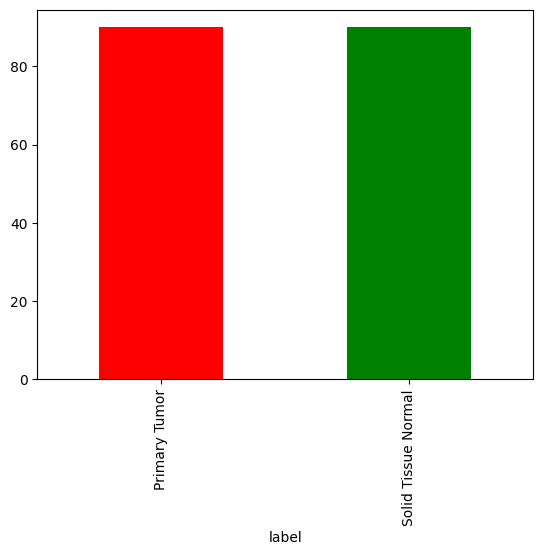

In [8]:
# 05 Creating Bar Plots with labels
colors = {'Primary Tumor': 'red', 'Solid Tissue Normal': 'green'}
data["label"].value_counts().plot.bar(color=[colors[key] for key in data["label"].value_counts().index])

## ✨ **Step 04**: Data Preprocessing - Preparing for Machine Learning

This crucial step transforms our raw gene expression data into a format suitable for machine learning algorithms. Effective preprocessing ensures model robustness and interpretability. Key objectives include:

*   **Separation of Features and Target**: Delineating the gene expression profiles (features) from the `type` column (target variable, i.e., Primary Tumor vs. Soliid Tisue Normal. This distinction is fundamental for supervised learning tasks.
*   **Handling Categorical Data**: Converting the categorical `type` variable into a numerical format, typically using techniques like Label Encoding, to enable algorithmic processing.
*   **Feature Scaling**: Standardizing or normalizing gene expression values to prevent features with larger ranges from dominating the learning process, ensuring fair contribution from all genes.
*   **Data Splitting**: Partitioning the dataset into training and testing sets to rigorously evaluate model performance on unseen data.

This meticulous preparation lays the groundwork for accurate biomarker identification and robust classification.

In [9]:
# 01 Separating The Class Labels (Solid Tissue Normal vs Primary Tumor) & Features
x_matrix = data.iloc[:, 2:]
y_matrix = data.iloc[:, 1]

In [10]:
# 1.1 Explore the shape of x
x_matrix.shape

(180, 16382)

In [11]:
#1.2 Explore the shape of y
y_matrix.shape

(180,)

In [12]:
# 02 Encoding y_matrix the data label (Primary Tumor 0 and solid tissue normal 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_matrix)

In [13]:
# 03 Display the mapping of original labels to encoded integers
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Label mapping: {label_mapping}")


Label mapping: {'Primary Tumor': np.int64(0), 'Solid Tissue Normal': np.int64(1)}


In [14]:
# 04 Display the first few encoded labels
print("\nFirst 5 encoded labels:")
display(pd.Series(y_encoded).head())


First 5 encoded labels:


,0
0,0
1,0
2,0
3,0
4,0


In [15]:
# 05 Explore Original Labels
print("Original Labels (y_matrix) value counts:")
display(y_matrix)

Original Labels (y_matrix) value counts:


,label
0,Primary Tumor
1,Primary Tumor
2,Primary Tumor
3,Primary Tumor
4,Primary Tumor
...,...
175,Solid Tissue Normal
176,Solid Tissue Normal
177,Solid Tissue Normal
178,Solid Tissue Normal


In [16]:
# 06 Explore en coded labels
print("\nEncoded Labels (y_encoded) value counts:")
display(pd.Series(y_encoded))


Encoded Labels (y_encoded) value counts:


,0
0,0
1,0
2,0
3,0
4,0
...,...
175,1
176,1
177,1
178,1


## 📈 **Step 05**: Data Stratification and Partitioning for Model Training and Validation

This pivotal phase focuses on the methodical division of our preprocessed gene expression dataset into distinct subsets: **training** and **testing**. This rigorous partitioning is indispensable for developing robust machine learning models and objectively assessing their generalization capabilities on unseen data.

Key objectives of this step include:
*   **Maintaining Data Integrity**: Ensuring that the distribution of biological labels (e.g., 'Primary Tumor' vs. 'Solid Tissue Normal') is preserved across the training and testing sets, particularly crucial for imbalanced datasets.
*   **Facilitating Unbiased Evaluation**: Providing a dedicated testing set allows for an honest appraisal of the model's performance, mitigating the risk of overfitting and ensuring its predictive accuracy on novel samples.
*   **Enabling Hyperparameter Tuning**: The training set can be further subdivided (e.g., using cross-validation) to fine-tune model parameters without compromising the integrity of the final test set evaluation.

In [17]:
# 01 Data Splitting
x_train, x_test, y_train, y_test = train_test_split(x_matrix, y_encoded, test_size=0.2, random_state=42)

## ✨ **Step 06**: Data Normalization and Scaling

This critical step is vital for preparing our gene expression data for machine learning algorithms. **Normalization and scaling** ensure that all features (gene expression values) contribute equally to the model's learning process, preventing features with larger numerical ranges from disproportionately influencing the model. By transforming the data to a common scale, we enhance the performance and convergence of various algorithms, leading to more robust and accurate biomarker identification.

Key objectives of this step include:
*   **Ensuring Equal Feature Contribution**: All gene expression values are transformed to a similar scale, preventing features with larger numerical ranges from dominating the learning process.
*   **Enhancing Algorithm Performance**: Many machine learning algorithms perform better when features are on a similar scale, leading to faster convergence and improved model stability.
*   **Improving Robustness and Accuracy**: Standardized data results in more robust models and contributes to more accurate biomarker identification.

In [18]:
# 01 Scale the data between 0, 1
MinMaxScaler_scaler = MinMaxScaler()
x_train = MinMaxScaler_scaler.fit_transform(x_train)
x_test = MinMaxScaler_scaler.transform(x_test)

In [19]:
# 02 Checking Normalized data set (X Train)
type(x_train)

numpy.ndarray

In [20]:
# 03 Checking normalized result
x_train[0,3]

np.float64(0.3023661610260713)

## ✨ **Step 07**: Feature Selection Using Mutual Information
Feature selection is a critical preprocessing step that aims to identify and select the most relevant genes (features) from our high-dimensional gene expression dataset. By reducing the number of features, we can improve model performance, reduce computational cost, and enhance the interpretability of our classification models. This is particularly important in bioinformatics where the number of genes often far exceeds the number of samples. Here, we utilize **Mutual Information**, a powerful non-parametric method, to quantify the dependency between each gene (feature) and the target variable (label). Genes with higher mutual information scores are considered more informative for distinguishing between biological states.

Key objectives of this step include:
*   **Dimensionality Reduction**: Eliminating redundant or irrelevant features to simplify the model and reduce the risk of overfitting.
*   **Improved Model Accuracy**: Selecting only the most informative features can lead to better predictive performance.
*   **Enhanced Interpretability**: Focusing on a smaller set of key genes makes the model easier to understand and allows for better biological insights into biomarker identification.
*   **Reduced Computational Cost**: Training models on fewer features requires less computational resources and time.

In [21]:
# 01 Seting up the Mutual Information selection
M_info = mutual_info_classif(x_train, y_train)

In [22]:
# 02 Select top n Features (n = 1000)
n_feature = 1000
selected_score_indice = np.argsort(M_info)[-n_feature:]
selected_score_indice

array([ 4753,  9957, 10441,  6985,  5307,  4575,  7492,  3707, 15483,
        5484,  3610, 12059,  6327,  5920,  7619,  9560, 15846,  8350,
       14253,  2952,  7844,  4139, 11656,  8771, 15954,  1974,  4508,
       12411, 10223,   713,  5924, 12927,  8583,  8552,   894,  2673,
        1801,  9642, 13221, 10071, 11887,  6166,  2037,  9338, 13941,
        9951, 11617,  6332,  9389,  1392,   970, 12290,  8030,  4602,
       10727, 12050,  9416,  5487,  5426, 10679,  1147,  1167,  4099,
         611,  5926,  9475, 10245, 16300, 14289,  9084, 14664,  7171,
       10710, 11965,  2419, 12977,   492,  5467,  5913, 12575,  8781,
        7999, 13643, 10295, 14733, 15671,  5407, 13438, 10420, 16269,
       15860, 15026,  7032, 12309,  6392, 15645,  4482,  1234,  9982,
        4536,  5547,  5007,  2260, 13073,  2208, 10422,  3137,  2634,
        9923, 10268,  2787, 14395, 12399,  8447, 14417,  3293,  8827,
       11237,   128,  9688,  5350,  1996, 12498, 13701,  1260,  7603,
       11325, 10616,

In [23]:
# 03 Selecting X train and X Test
x_train_selected = x_train[:, selected_score_indice]
x_test_selected = x_test[:, selected_score_indice]

In [24]:
# 04 Checking X train Shape
x_train_selected.shape

(144, 1000)

In [25]:
x_test_selected.shape

(36, 1000)

## ✨ **Step 08**: Model Train (Random Forest)

This crucial stage involves training a machine learning model, specifically a Random Forest Classifier, using the preprocessed and feature-selected gene expression data. The objective is to build a robust predictive model that can accurately classify between different biological states (e.g., Primary Tumor vs. Solid Tissue Normal).

Key objectives of this step include:
*   **Model Initialization**: Setting up the Random Forest classifier with appropriate parameters.
*   **Training**: Fitting the model to the training data (`x_train_selected` and `y_train`) to learn the complex relationships between gene expression patterns and the biological labels.
*   **Preparation for Evaluation**: Creating a trained model that will be used to make predictions on unseen test data.

In [26]:
# 01 Setting up the random forest Classifier
RF = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42,max_features=0.20))

In [27]:
# 02 Create a 5-fold cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [28]:
# 03 Perform Cross-Validation on the training data
cv_scores = cross_val_score(RF, x_train_selected, y_train, cv=skf)

In [29]:
# 04 Observing cross validation results
print(f"Accuracy for each fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Accuracy for each fold: [1.         1.         1.         0.96551724 1.        ]
Mean CV Accuracy: 0.9931
Standard Deviation: 0.0138


In [30]:
# 02 Fitting The model
RF.fit(x_train_selected, y_train)
# 03 Fitting The Prediction
y_pred = RF.predict(x_test_selected)
# 04 Observing the probability
prob_pred = RF.predict_proba(x_test_selected)

In [31]:
prob_pred

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.34, 0.66],
       [0.01, 0.99],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       [0.01, 0.99],
       [0.  , 1.  ],
       [0.06, 0.94],
       [0.  , 1.  ],
       [0.94, 0.06],
       [0.03, 0.97],
       [0.98, 0.02],
       [0.94, 0.06],
       [0.99, 0.01],
       [0.05, 0.95],
       [0.  , 1.  ],
       [0.76, 0.24],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.99, 0.01],
       [0.  , 1.  ],
       [0.92, 0.08],
       [0.98, 0.02],
       [0.02, 0.98],
       [0.01, 0.99],
       [0.04, 0.96],
       [0.99, 0.01],
       [0.11, 0.89],
       [0.05, 0.95],
       [0.93, 0.07],
       [0.99, 0.01]])

## ✨ **Step 09**: Model Evaluation
This crucial phase involves a rigorous evaluation of our trained Random Forest Classifier's performance. By applying various metrics, we assess the model's ability to accurately classify between different biological states (e.g., Primary Tumor vs. Solid Tissue Normal) on unseen data. This evaluation helps us understand the model's strengths and weaknesses, ensuring its reliability and generalizability for biomarker identification.

Key objectives of this step include:
*   **Quantifying Predictive Accuracy**: Calculating metrics such as accuracy, precision, recall, and F1-score to measure the model's overall correctness and its ability to identify positive and negative classes.
*   **Assessing Discrimination Power**: Utilizing the Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) to evaluate the model's ability to distinguish between the two classes across various classification thresholds.
*   **Understanding Classification Errors**: Generating a confusion matrix to visualize the types of errors made by the model (false positives, false negatives) and gain deeper insights into its performance characteristics.
*   **Ensuring Balanced Performance**: Evaluating balanced accuracy to account for potential class imbalances in the dataset and ensure a fair assessment of the model's performance on both classes.

In [32]:
# 01 Prediction of Accuracy
accuracy = np.round(accuracy_score(y_test, y_pred), 3)
print(f"Accuracy: {accuracy}")

Accuracy: 0.972


In [33]:
# 02 Prediction of Precition score
precision = np.round(precision_score(y_test, y_pred, average= "weighted"), 3)
print(f"Precision: {precision}")

Precision: 0.974


In [34]:
# 03 Prediction of recall
recall = np.round(recall_score(y_test, y_pred, average= "weighted"), 3)
print(f"Recall: {recall}")

Recall: 0.972


In [35]:
# 04 Prediction of F1 score
F1 = np.round(f1_score(y_test, y_pred, average= "weighted"), 3)
print(f"F1 Score: {F1}")

F1 Score: 0.972


In [36]:
# 05 Making Overall report
report = classification_report(y_test, y_pred, target_names=['Solid Tissue Normal', 'Primary Tumor'])
print(report)

                     precision    recall  f1-score   support

Solid Tissue Normal       1.00      0.94      0.97        18
      Primary Tumor       0.95      1.00      0.97        18

           accuracy                           0.97        36
          macro avg       0.97      0.97      0.97        36
       weighted avg       0.97      0.97      0.97        36



## ✨ **Step 10**: Confusion Matrix
The confusion matrix is a crucial tool for evaluating the performance of our classification model. It provides a detailed breakdown of correct and incorrect predictions made by the model, categorized by class.

Key objectives of this step include:
*   **Visualizing Performance**: Representing the number of true positives, true negatives, false positives, and false negatives in a clear, tabular format.
*   **Understanding Error Types**: Gaining insight into which classes are being confused by the model, helping to identify specific areas for improvement.
*   **Calculating Derived Metrics**: Enabling the calculation of various performance metrics (e.g., precision, recall, F1-score, and accuracy) directly from its values.
*   **Assessing Model Effectiveness**: Providing a comprehensive view of how well the model discriminates between 'Primary Tumor' and 'Solid Tissue Normal' samples.

In [37]:
# 01 Creating Confusion Matrix
c_mat = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(c_mat, index=['Solid Tissue Normal', 'Primary Tumor'], columns=['Solid Tissue Normal', 'Primary Tumor'])

In [38]:
# 02 Observing the data frame
cm_df

,Solid Tissue Normal,Primary Tumor
Solid Tissue Normal,17,1
Primary Tumor,0,18


Text(0.5, 1.0, 'Confusion Matrix')

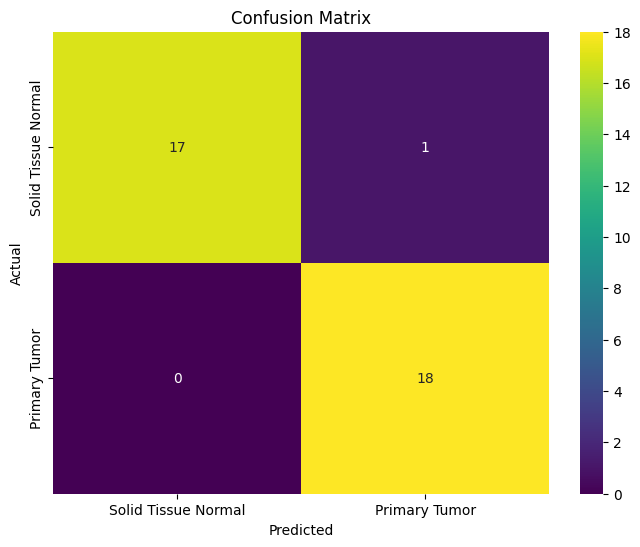

In [39]:
# 03 Visualize The Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

## ✨ **Step 11**: Receiver Operating Characteristic (ROC) Curve and Area Under the Curve (AUC)

The Receiver Operating Characteristic (ROC) curve is a fundamental visualization tool for assessing the diagnostic ability of a binary classifier as its discrimination threshold is varied. In bioinformatics, it's particularly valuable for evaluating models designed to distinguish between disease states (e.g., Primary Tumor) and normal conditions (e.g., Solid Tissue Normal).

The Area Under the Curve (AUC) quantifies the entire two-dimensional area underneath the entire ROC curve. It provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 indicates a perfect classifier, while an AUC of 0.5 suggests a classifier no better than random guessing. For biomarker identification, a high AUC signifies that our gene expression signature effectively separates the two biological classes.

Key objectives of this step include:
*   **Visualizing Discriminatory Power**: The ROC curve graphically illustrates the trade-off between the True Positive Rate (Sensitivity) and the False Positive Rate (1-Specificity) at various threshold settings.
*   **Quantifying Overall Performance**: The AUC score provides a single, robust metric to summarize the model's ability to distinguish between classes, independent of the chosen classification threshold.
*   **Benchmarking Model Robustness**: Comparing AUC values is crucial for assessing the efficacy of different models or feature sets in a biomarker discovery context.

In [40]:
# 01 Calculate the ROC curve and AUC
# Get probabilities for the positive class (class 1: Solid Tissue Normal)
prob_positive_class = prob_pred[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, prob_positive_class)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.3f}")

AUC Score: 1.000


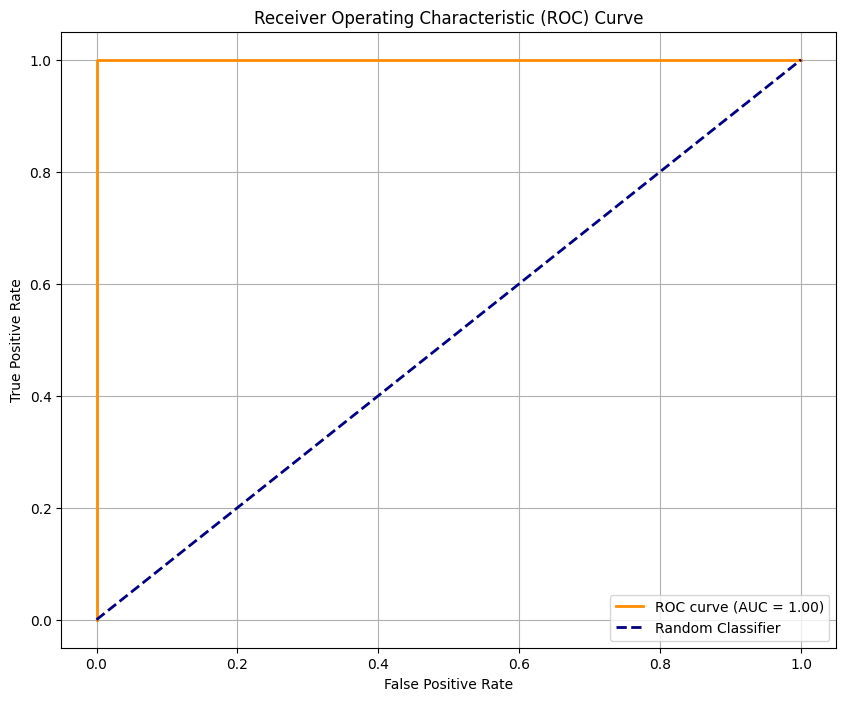

In [41]:
# 02 Plot the ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## ✨ **Step 12**: Feature Importance

Identifying the most important features (genes) from our dataset is a crucial aspect of biomarker discovery. Feature importance helps us understand which genes contribute most significantly to the model's ability to classify between 'Primary Tumor' and 'Solid Tissue Normal' samples. This step aims to:

*   **Pinpoint Key Biomarkers**: Highlight the genes that are most influential in the classification process, potentially serving as biological markers for disease states.
*   **Enhance Interpretability**: Provide insights into the biological mechanisms underpinning the classification, making the model's decisions more understandable.
*   **Guide Further Research**: Direct future experimental validation efforts towards the most promising gene candidates.

Since we used Mutual Information for feature selection, we can leverage the `M_info` array to visualize the importance of each feature.

In [42]:
# 1. Fit the model first to understand feature importance
RF.fit(x_train_selected, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(max_features=0.2,
                                                     random_state=42))

In [43]:
# 2. Extract feature importance scores
importances = RF.estimators_[0].feature_importances_

In [44]:
# 3. Retrieve gene names from the original dataframe columns
feature_names = data.columns[2:][selected_score_indice]

In [45]:
# 4. Create a DataFrame and sort by importance in descending order
feature_importance_df = pd.DataFrame({'Gene': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

In [46]:
# 5 Select the top 20 biomarkers
top_20_genes = feature_importance_df.head(20)

In [47]:
print("Top 20 Biomarker Genes for your project:")
print(top_20_genes)

Top 20 Biomarker Genes for your project:
                   Gene  Importance
999  ENSG00000136158.12    0.137001
997  ENSG00000161649.13    0.129164
998  ENSG00000165072.10    0.087815
992   ENSG00000187824.9    0.058095
988  ENSG00000099953.10    0.048345
993  ENSG00000182463.16    0.039449
982   ENSG00000168497.5    0.038659
985  ENSG00000123500.10    0.038362
991  ENSG00000149090.12    0.038358
995  ENSG00000145777.15    0.029458
960   ENSG00000111404.7    0.029450
996  ENSG00000168079.17    0.020000
989   ENSG00000154736.6    0.019726
990   ENSG00000177098.9    0.019722
969  ENSG00000137225.13    0.019718
981  ENSG00000154721.15    0.019175
774  ENSG00000143748.18    0.018923
954  ENSG00000135451.13    0.018630
883  ENSG00000170271.11    0.010000
896  ENSG00000135046.14    0.010000


/tmp/ipykernel_5515/1991655582.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Gene', data=top_20_genes, palette='viridis')


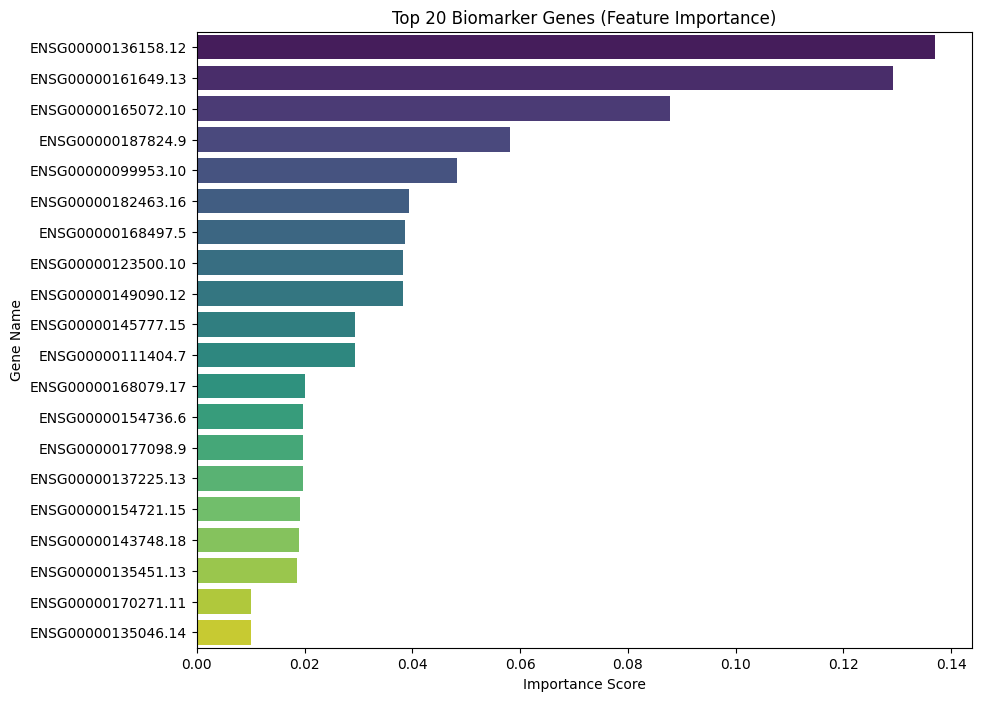

In [48]:
# 6. Visualization using a bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Gene', data=top_20_genes, palette='viridis')
plt.title('Top 20 Biomarker Genes (Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Gene Name')
plt.show()

## **Step 13**: Evaluation with Top 20 Biomarkers

Having identified the top 20 biomarker genes based on their importance, this final evaluation step aims to assess the performance of our Random Forest Classifier using *only* these selected features. This is crucial for several reasons:

*   **Validation of Feature Selection**: It confirms whether the chosen top biomarkers are indeed sufficient for maintaining high classification accuracy, thereby validating our feature selection methodology.
*   **Model Simplification**: By training a model with a reduced feature set, we aim for a simpler, more interpretable model that is less prone to overfitting and more computationally efficient.
*   **Biological Relevance**: A high-performing model built on a minimal set of biologically relevant genes strengthens the case for these genes as robust biomarkers.

We will re-evaluate the model's accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC curve using only the gene expression data corresponding to these top 20 features. This will provide a concise and focused assessment of the biomarker panel's predictive power.

In [49]:
# 01 Extract the indices of the top 20 genes
top_20_indices = top_20_genes.index

In [50]:
# 02 Create new training and testing sets with only these 20 features
x_train_top20 = x_train_selected[:, top_20_indices]
x_test_top20 = x_test_selected[:, top_20_indices]

In [51]:
# 03 Retrain the model using only the top 20 biomarkers
RF_small = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
RF_small.fit(x_train_top20, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42))

In [52]:
# 04 Check the performance
small_acc = RF_small.score(x_test_top20, y_test)
print(f"Accuracy using only top 20 genes: {small_acc:.4f}")

Accuracy using only top 20 genes: 0.9722


## **Step 14**: Gene Symbol Mapping

After identifying potential biomarker genes through our machine learning model, the next crucial step in bioinformatics is to map these gene identifiers (e.g., ENSG IDs) to their more commonly recognized gene symbols. This mapping is essential for several reasons:

*   **Biological Interpretation**: Gene symbols provide a human-readable and standardized name for each gene, making it easier for biologists and researchers to understand their function, associated pathways, and relevance in disease.
*   **Literature Search and Annotation**: Standard gene symbols facilitate searching biological databases (e.g., NCBI Gene, Ensembl, UniProt) and scientific literature to gather more information about the genes, their roles, and any known associations with the biological condition under study.
*   **Communication and Collaboration**: Using recognized gene symbols improves communication within the scientific community and fosters easier collaboration by ensuring everyone refers to the same gene consistently.

This step typically involves using bioinformatics tools or libraries that can query public databases to retrieve gene symbols based on the provided identifiers. We will aim to convert the ENSG identifiers of our top biomarker candidates into their corresponding gene symbols for better interpretability and to facilitate further biological validation.

In [53]:
# 01 Installing required Library
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00


In [54]:
# 02 Import needed Library
import mygene

In [55]:
# 03 Initialize the MyGene client
mg = mygene.MyGeneInfo()

In [56]:
# 04 Get the list of Ensembl IDs from your top_20_genes
ensembl_ids_with_versions = top_20_genes['Gene'].tolist()
clean_ids = [gene.split('.')[0] for gene in ensembl_ids_with_versions]

In [57]:
# 05 Query the database to find corresponding gene symbols
result = mg.querymany(clean_ids, scopes='ensembl.gene', fields='symbol', species='human')

INFO:biothings.client:querying 1-20 ...
INFO:biothings.client:Finished.


In [58]:
# 06 Create a dictionary to map IDs to Names
id_to_symbol = {res['query']: res.get('symbol', 'N/A') for res in result}

In [59]:
# 07 Add the gene names to your Top 20 DataFrame
top_20_genes['Clean_ID'] = clean_ids
top_20_genes['Gene_Symbol'] = top_20_genes['Clean_ID'].map(id_to_symbol)

/tmp/ipykernel_5515/632052455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_genes['Clean_ID'] = clean_ids
/tmp/ipykernel_5515/632052455.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_genes['Gene_Symbol'] = top_20_genes['Clean_ID'].map(id_to_symbol)


In [60]:
# 08 Print the Results
print("Name of top 20 genes:")
print(top_20_genes[['Gene', 'Gene_Symbol', 'Importance']])

Name of top 20 genes:
                   Gene Gene_Symbol  Importance
999  ENSG00000136158.12       SPRY2    0.137001
997  ENSG00000161649.13     CD300LG    0.129164
998  ENSG00000165072.10      MAMDC2    0.087815
992   ENSG00000187824.9     TMEM220    0.058095
988  ENSG00000099953.10       MMP11    0.048345
993  ENSG00000182463.16       TSHZ2    0.039449
982   ENSG00000168497.5      CAVIN2    0.038659
985  ENSG00000123500.10     COL10A1    0.038362
991  ENSG00000149090.12       PAMR1    0.038358
995  ENSG00000145777.15        TSLP    0.029458
960   ENSG00000111404.7       RERGL    0.029450
996  ENSG00000168079.17      SCARA5    0.020000
989   ENSG00000154736.6     ADAMTS5    0.019726
990   ENSG00000177098.9       SCN4B    0.019722
969  ENSG00000137225.13      CAPN11    0.019718
981  ENSG00000154721.15        JAM2    0.019175
774  ENSG00000143748.18         NVL    0.018923
954  ENSG00000135451.13       TROAP    0.018630
883  ENSG00000170271.11      FAXDC2    0.010000
896  ENSG000001350

In [61]:
# 09 Export Result in CSV with Top 20 Genes
top_20_genes.to_csv('top_20_biomarker_genes.csv', index=False)
print("Top 20 biomarker genes exported to 'top_20_biomarker_genes.csv'")

Top 20 biomarker genes exported to 'top_20_biomarker_genes.csv'


## **Step 15**: Pathway Enrichment Analysis of Top 20 Genes

After identifying a set of potential biomarker genes, the next logical step in bioinformatics is to perform **Pathway Enrichment Analysis**. This analysis helps to put the list of individual genes into a broader biological context, identifying overrepresented biological pathways, functions, or diseases associated with these genes.

Key objectives of this step include:
*   **Biological Contextualization**: Moving beyond individual genes to understand the biological processes they collectively influence.
*   **Mechanism Elucidation**: Gaining insights into the molecular mechanisms and regulatory networks that might be disrupted in the disease state.
*   **Prioritization of Targets**: Identifying key pathways that could be targeted for therapeutic intervention or further experimental investigation.
*   **Hypothesis Generation**: Generating new hypotheses about disease etiology and progression based on the enriched pathways.

This step typically involves using specialized bioinformatics tools or web-based platforms that can query pathway databases (e.g., KEGG, Reactome, GO) with our list of gene symbols. The output usually includes a list of enriched pathways, their associated genes, and statistical significance scores (e.g., p-values, FDR adjusted p-values).

In [62]:
# 01 Installing necessary Libraries
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 11.4 MB/s eta 0:00:00


In [63]:
# 02 Import the library
import gseapy as gp

In [64]:
# 03 Top 20 Genes
gene_list = top_20_genes['Gene_Symbol'].tolist()

In [65]:
# 04 Running KEGG Analysis
enr = gp.enrichr(gene_list=gene_list,
                 gene_sets=['KEGG_2021_Human'],
                 organism='human', # Fixed here
                 cutoff=0.05,
                 outdir=None)

print(enr.results.head())

          Gene_set                                               Term Overlap  \
0  KEGG_2021_Human  Epithelial cell signaling in Helicobacter pylo...    1/70   
1  KEGG_2021_Human                   Protein digestion and absorption   1/103   
2  KEGG_2021_Human                  Ribosome biogenesis in eukaryotes   1/108   
3  KEGG_2021_Human               Leukocyte transendothelial migration   1/114   
4  KEGG_2021_Human                            Cell adhesion molecules   1/148   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.067752          0.195207            0                     0   15.187643   
1  0.098157          0.195207            0                     0   10.256966   
2  0.102681          0.195207            0                     0    9.775209   
3  0.108081          0.195207            0                     0    9.253377   
4  0.138104          0.195207            0                     0    7.100967   

   Combined Score    Genes  
0  

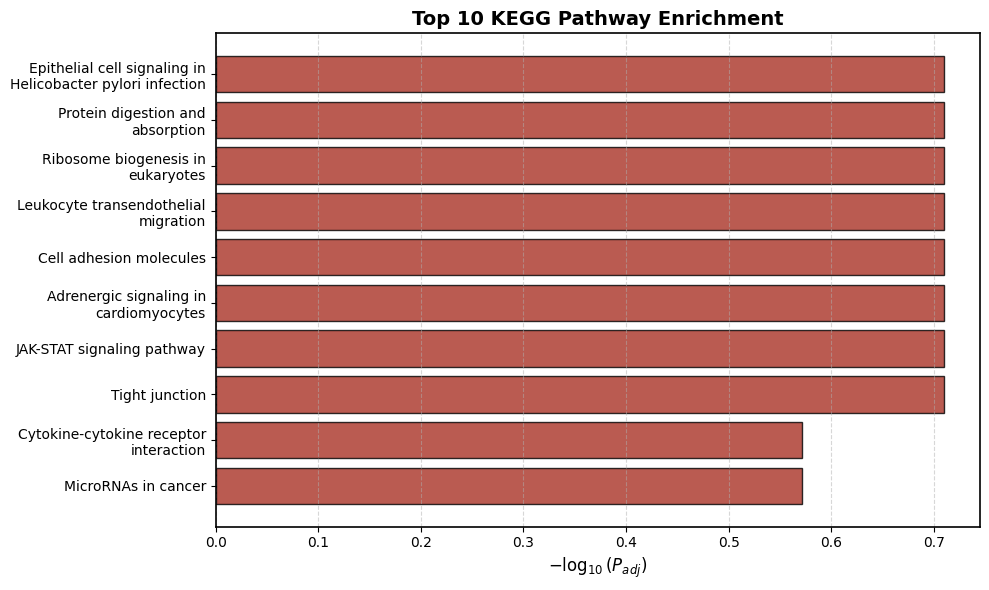

In [73]:
import textwrap

# 05 Visualize the KEGG pathway enrichment results
kegg_results = enr.results[enr.results['Gene_set'] == 'KEGG_2021_Human'].head(10)

if not kegg_results.empty:
    fig_kegg, ax_kegg = plt.subplots(figsize=(10, 6))

    # Wrap pathway names for better readability
    labels_kegg = [textwrap.fill(term, width=30) for term in kegg_results['Term']]

    ax_kegg.barh(labels_kegg, -np.log10(kegg_results['Adjusted P-value']), color='#A93226', edgecolor='black', alpha=0.8)
    ax_kegg.set_title('Top 10 KEGG Pathway Enrichment', fontsize=14, fontweight='bold')
    ax_kegg.set_xlabel(r'$-\log_{10}(\mathit{P}_{adj})$', fontsize=12)
    ax_kegg.invert_yaxis()
    ax_kegg.tick_params(axis='y', labelsize=10)
    ax_kegg.grid(axis='x', linestyle='--', alpha=0.5)

    for spine in ax_kegg.spines.values():
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()
else:
    print("No significant KEGG pathways found to visualize.")

In [74]:
# 06 Running Reactome Analysis
enr_reactome = gp.enrichr(gene_list=gene_list,
                          gene_sets=['Reactome_2022'],
                          organism='human',
                          cutoff=0.05,
                          outdir=None)

print(enr_reactome.results.head())

        Gene_set                                               Term Overlap  \
0  Reactome_2022    Extracellular Matrix Organization R-HSA-1474244   5/291   
1  Reactome_2022  Degradation Of Extracellular Matrix R-HSA-1474228   3/109   
2  Reactome_2022  Formyl Peptide Receptors Bind Formyl Peptides ...     1/8   
3  Reactome_2022     Spry Regulation Of FGF Signaling R-HSA-1295596    1/16   
4  Reactome_2022                    Muscle Contraction R-HSA-397014   2/196   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.000008          0.000523            0                     0   22.953380   
1  0.000168          0.005369            0                     0   33.086570   
2  0.007973          0.113536            0                     0  150.172932   
3  0.015886          0.113536            0                     0   70.052632   
4  0.016167          0.113536            0                     0   11.332188   

   Combined Score                           

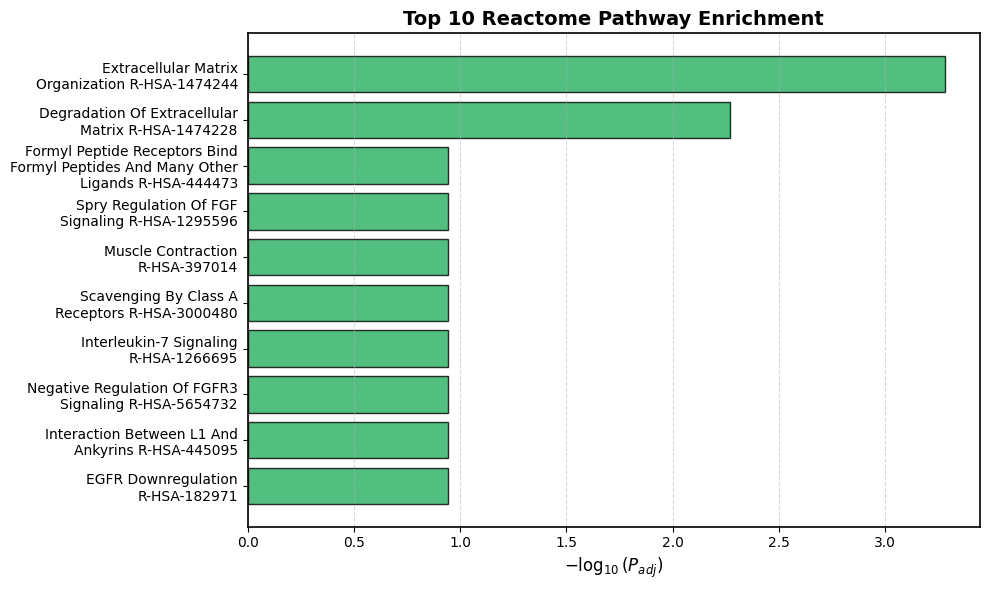

In [75]:
# 07 Visualize the Reactome pathway enrichment results
reactome_results = enr_reactome.results[enr_reactome.results['Gene_set'] == 'Reactome_2022'].head(10)

if not reactome_results.empty:
    fig_reactome, ax_reactome = plt.subplots(figsize=(10, 6))

    # Wrap pathway names for better readability
    labels_reactome = [textwrap.fill(term, width=30) for term in reactome_results['Term']]

    ax_reactome.barh(labels_reactome, -np.log10(reactome_results['Adjusted P-value']), color='#27AE60', edgecolor='black', alpha=0.8)
    ax_reactome.set_title('Top 10 Reactome Pathway Enrichment', fontsize=14, fontweight='bold')
    ax_reactome.set_xlabel(r'$-\log_{10}(\mathit{P}_{adj})$', fontsize=12)
    ax_reactome.invert_yaxis()
    ax_reactome.tick_params(axis='y', labelsize=10)
    ax_reactome.grid(axis='x', linestyle='--', alpha=0.5)

    for spine in ax_reactome.spines.values():
        spine.set_linewidth(1.2)

    plt.tight_layout()
    plt.show()
else:
    print("No significant Reactome pathways found to visualize.")

In [77]:
# 08 Exploring more specific databases (WikiPathways and MSigDB Hallmark)
additional_gene_sets = ['WikiPathway_2021_Human', 'MSigDB_Hallmark_2020']

enr_extra = gp.enrichr(gene_list=gene_list,
                       gene_sets=additional_gene_sets,
                       organism='human',
                       cutoff=0.05,
                       outdir=None)

# Identify column name for compatibility
col_name = 'Gene_set' if 'Gene_set' in enr_extra.results.columns else 'Gene_Set'

# Display results for WikiPathways
print("Top 5 WikiPathways:")
print(enr_extra.results[enr_extra.results[col_name] == 'WikiPathway_2021_Human'].head(5))

Top 5 WikiPathways:
                 Gene_set                                               Term  \
0  WikiPathway_2021_Human  Endochondral Ossification with Skeletal Dyspla...   
1  WikiPathway_2021_Human                    Endochondral Ossification WP474   
2  WikiPathway_2021_Human                    Matrix Metalloproteinases WP129   
3  WikiPathway_2021_Human  Development and heterogeneity of the ILC famil...   
4  WikiPathway_2021_Human        Prostaglandin Synthesis and Regulation WP98   

  Overlap   P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0    2/64  0.001845          0.017531            0                     0   
1    2/64  0.001845          0.017531            0                     0   
2    1/30  0.029590          0.145624            0                     0   
3    1/32  0.031533          0.145624            0                     0   
4    1/45  0.044071          0.145624            0                     0   

   Odds Ratio  Combined Score            G

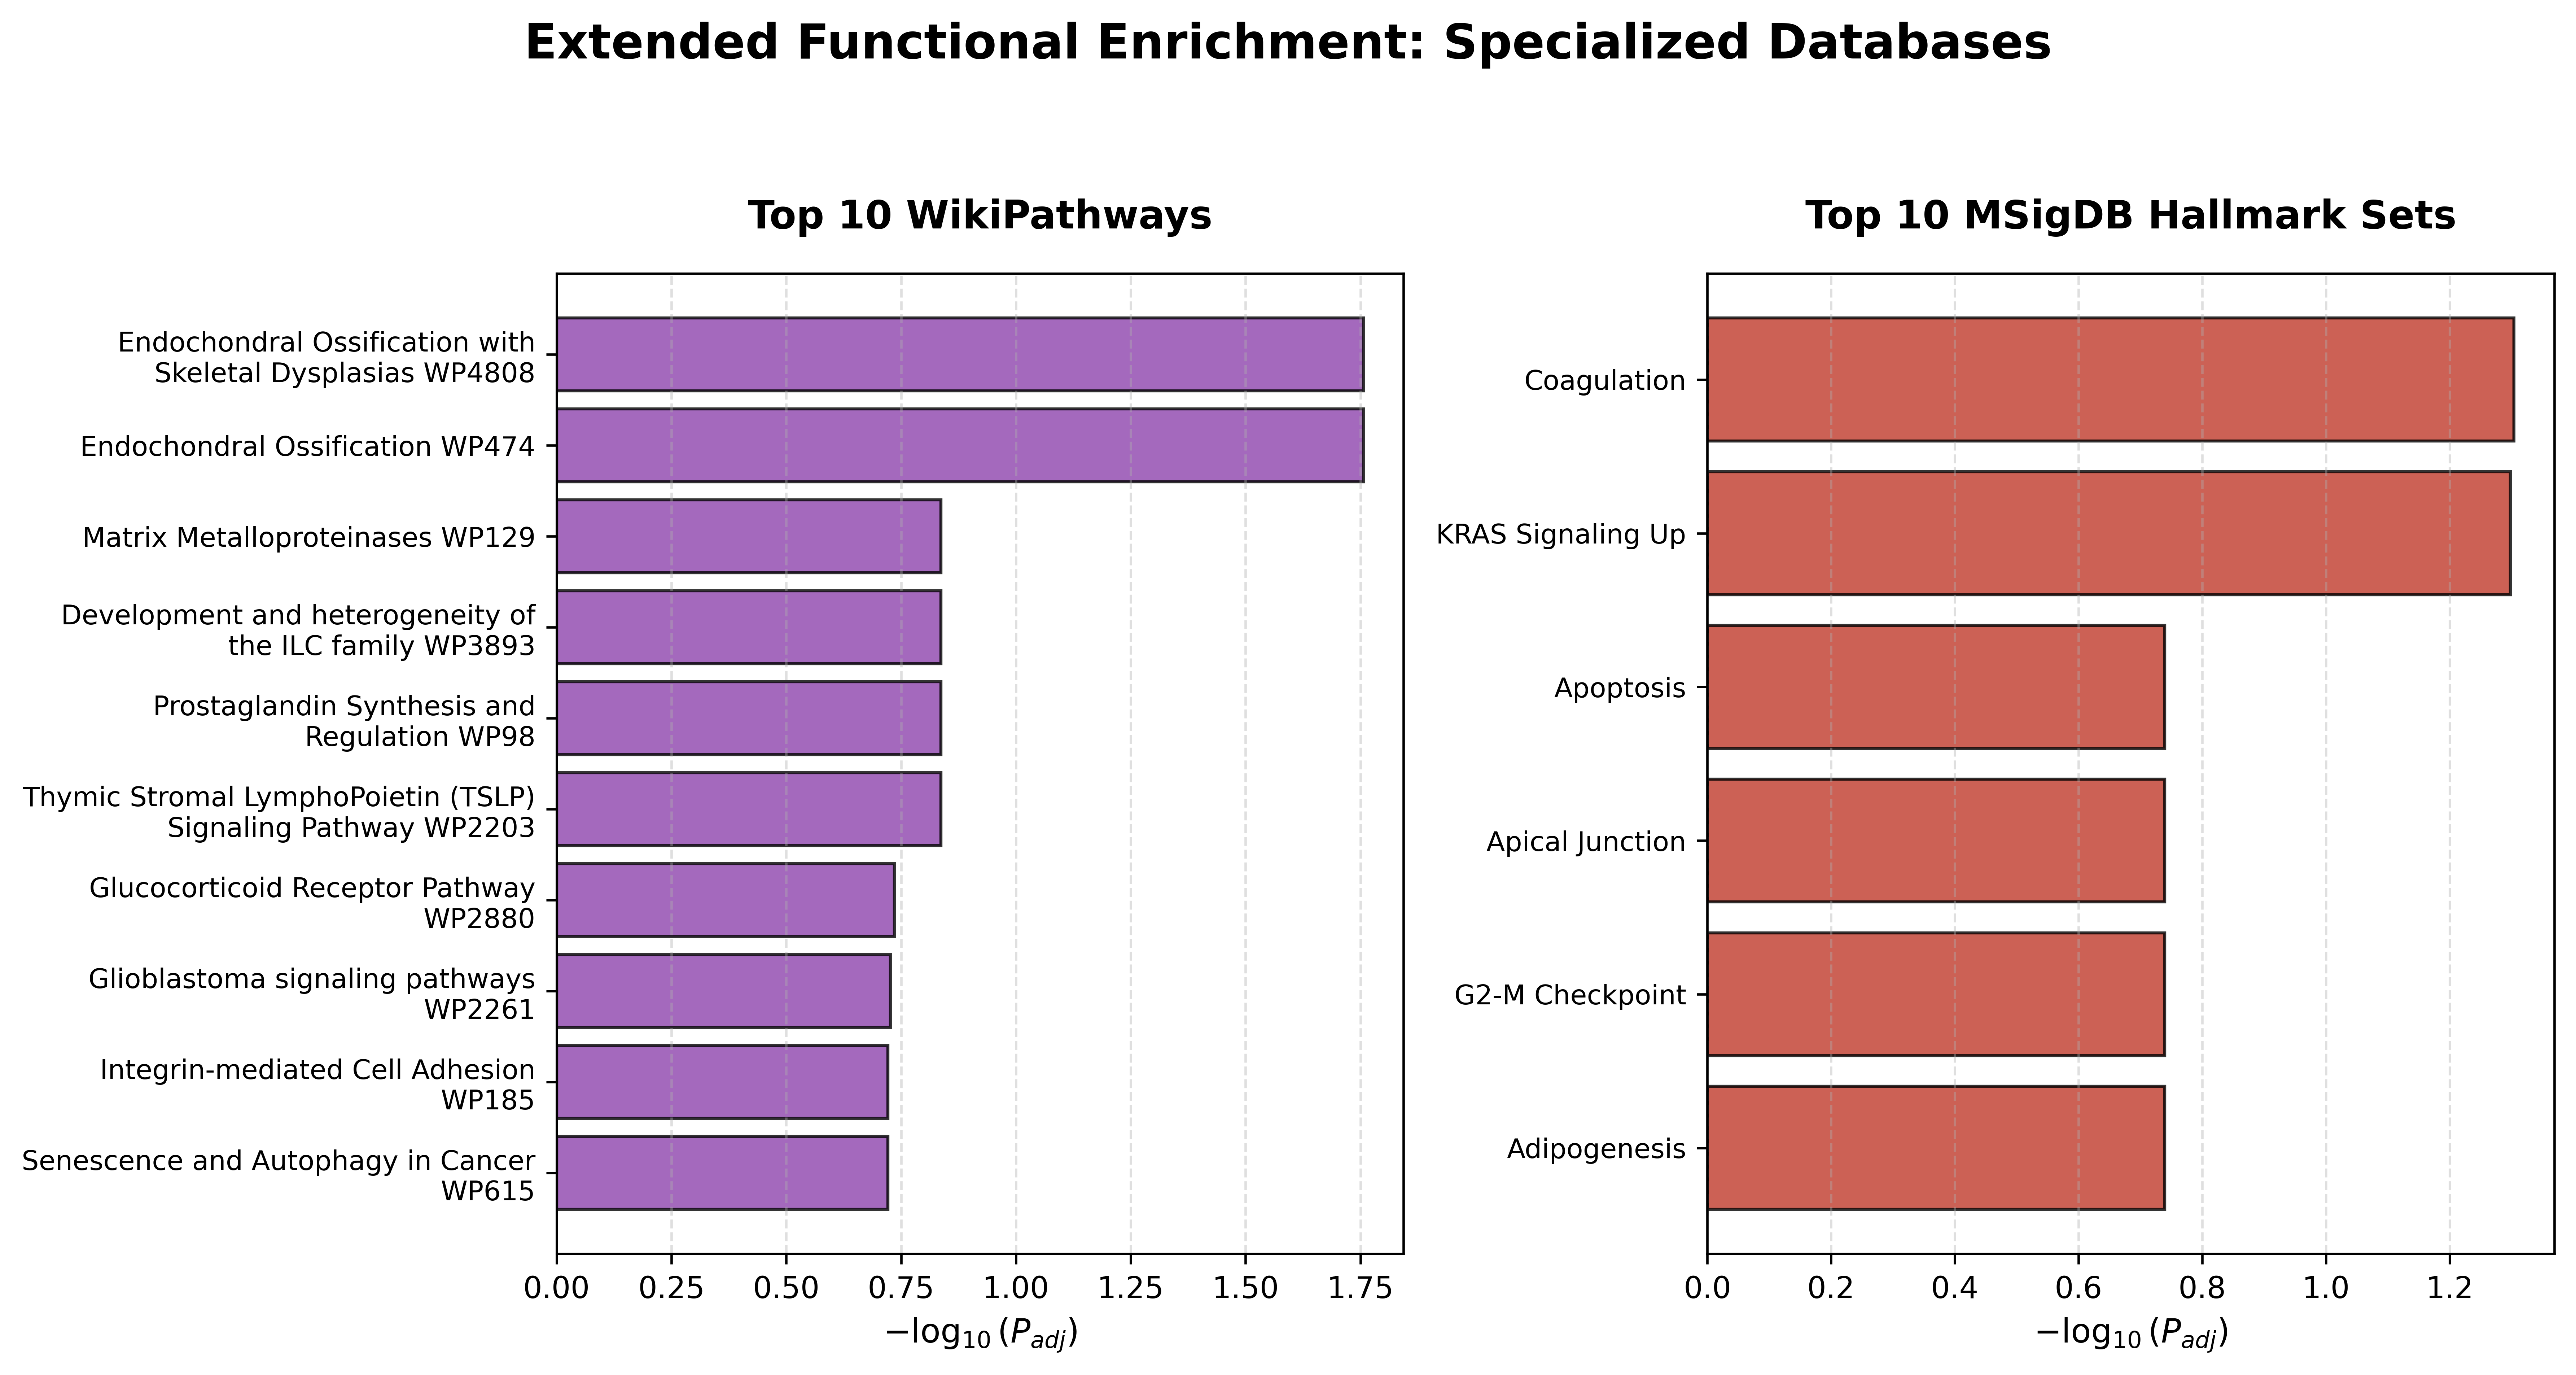

Extended pathway plot saved as: Extended_Pathways_Publication.png


In [79]:
# 09 Visualization for Additional Pathways (WikiPathways & MSigDB Hallmark)
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# Set up a 1x2 multi-panel figure for the new databases
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

# Define the sets we just analyzed
additional_sets = ['WikiPathway_2021_Human', 'MSigDB_Hallmark_2020']
add_titles = ['Top 10 WikiPathways', 'Top 10 MSigDB Hallmark Sets']
add_colors = ['#8E44AD', '#C0392B'] # Deep purple and Rich red for distinction

# Identify column name for compatibility
col_name = 'Gene_set' if 'Gene_set' in enr_extra.results.columns else 'Gene_Set'

for i, gs in enumerate(additional_sets):
    # Filter and sort the top 10 significant results
    results = enr_extra.results[enr_extra.results[col_name] == gs].head(10)

    if not results.empty:
        # Wrap long pathway names for clean display
        labels = [textwrap.fill(term, width=35) for term in results['Term']]

        # Plotting -log10(Adjusted P-value)
        axes[i].barh(labels, -np.log10(results['Adjusted P-value']),
                     color=add_colors[i], edgecolor='black', alpha=0.8)

        # Scientific formatting and styling
        axes[i].set_title(add_titles[i], fontsize=13, fontweight='bold', pad=15)
        axes[i].set_xlabel(r'$-\log_{10}(\mathit{P}_{adj})$', fontsize=11)
        axes[i].invert_yaxis()  # Highest significance at the top
        axes[i].tick_params(axis='y', labelsize=9)
        axes[i].grid(axis='x', linestyle='--', alpha=0.4)
    else:
        axes[i].text(0.5, 0.5, f'No Significant Results in\n{gs}',
                     ha='center', va='center', fontsize=12)

# Global formatting
plt.suptitle('Extended Functional Enrichment: Specialized Databases',
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Save the final publication-ready plot
output_file_extra = "Extended_Pathways_Publication.png"
plt.savefig(output_file_extra, dpi=600, bbox_inches='tight')

plt.show()
print(f"Extended pathway plot saved as: {output_file_extra}")

In [80]:
# 10 Drug-Gene Enrichment (Using DSigDB)
import gseapy as gp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Using DSigDB - One of the most comprehensive drug-gene interaction databases
# This doesn't require an external API call like DGIdb
drug_gene_sets = ['DSigDB']

try:
    enr_drugs = gp.enrichr(gene_list=gene_list,
                           gene_sets=drug_gene_sets,
                           organism='human',
                           cutoff=0.5, # Increased cutoff to see more potential drug candidates
                           outdir=None)

    # Check if results were found
    if not enr_drugs.results.empty:
        # Filtering for top 10 potential drug candidates
        top_drugs = enr_drugs.results.head(10)
        print("Top Drug Candidates identified via DSigDB:")
        print(top_drugs[['Term', 'Adjusted P-value', 'Genes']].head())
    else:
        print("No significant drug candidates found for this gene set in DSigDB.")
except Exception as e:
    print(f"An error occurred during enrichment: {e}")

Top Drug Candidates identified via DSigDB:
                                                Term  Adjusted P-value  \
0                          CHEMBL475540 TTD 00006054          0.020084   
1  1,1-Bis(4-hydroxyphenyl)-2-phenylbut-1-ene CTD...          0.396691   
2                             Dasatinib CTD 00004330          0.396691   
3                                 ethaverine HL60 UP          0.396691   
4                                 salbutamol HL60 UP          0.396691   

                  Genes  
0         MMP11;ADAMTS5  
1                 ANXA1  
2  ADAMTS5;MAMDC2;SPRY2  
3                 ANXA1  
4                 ANXA1  


/tmp/ipykernel_5515/2338468149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=-np.log10(plot_data['Adjusted P-value']),


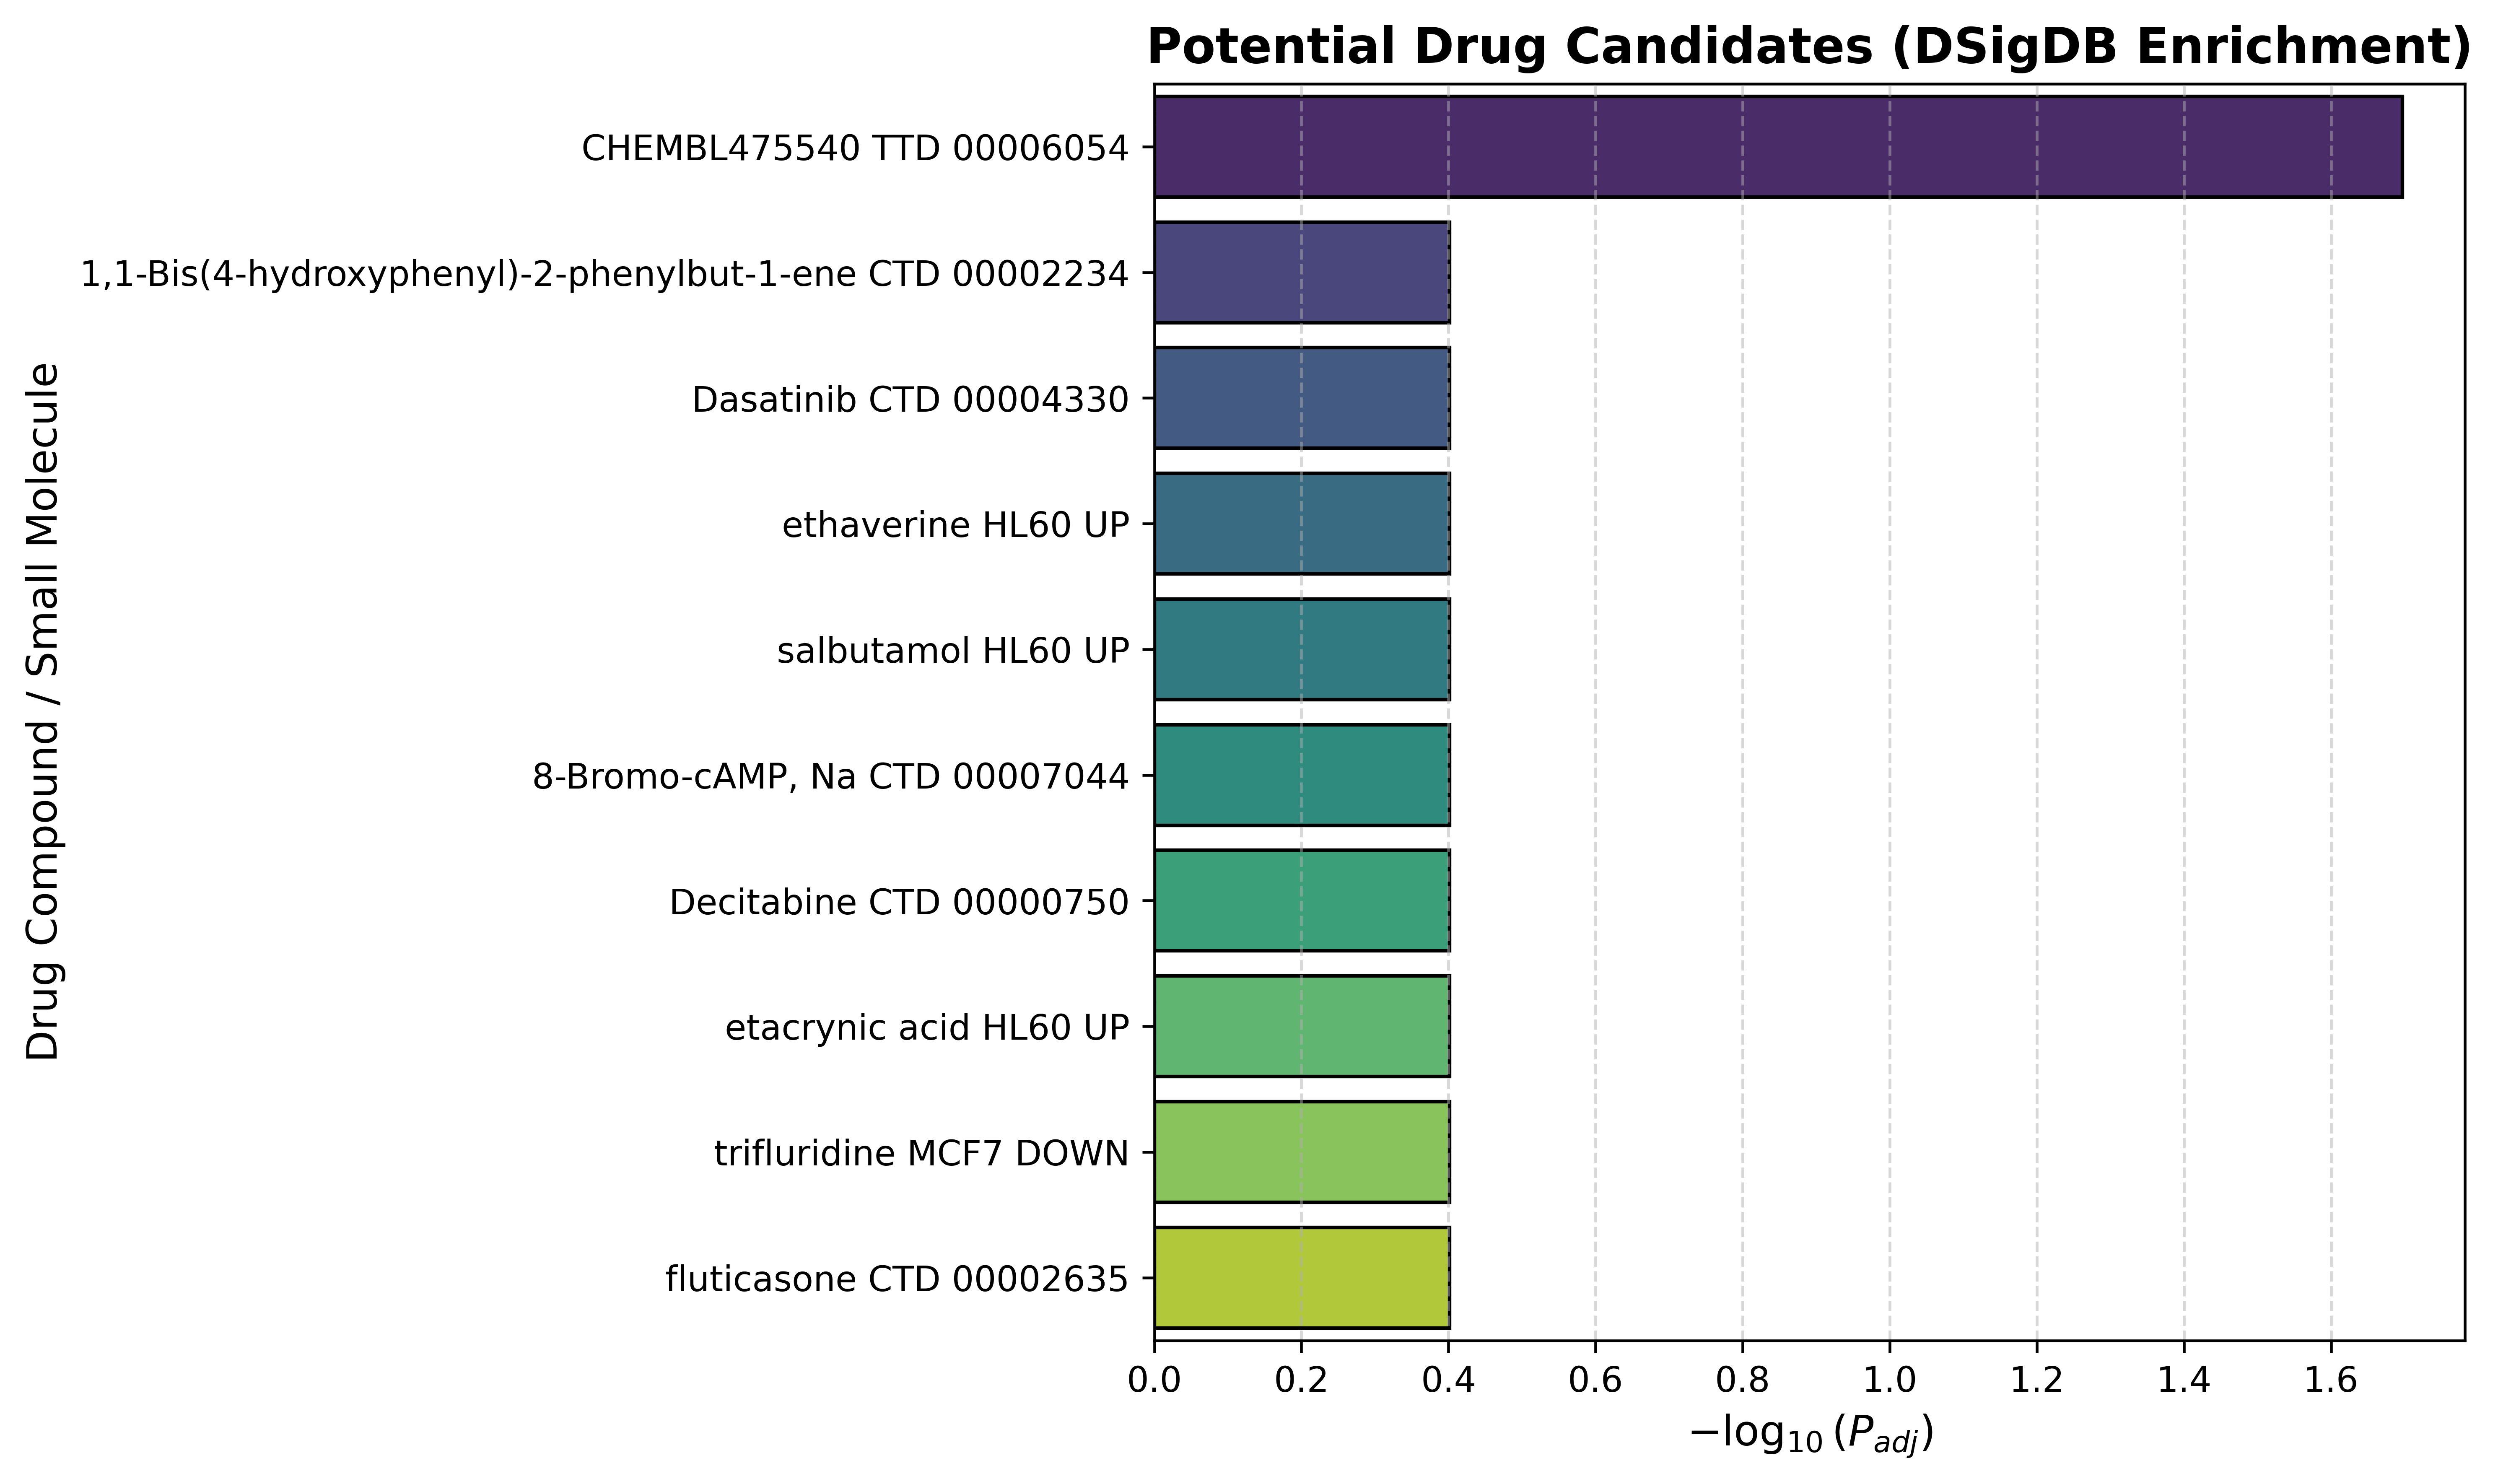

In [81]:
# 11 Visualization of Drug Candidates
if not enr_drugs.results.empty:
    plt.figure(figsize=(10, 6), dpi=600)

    # Selecting top 10 drugs
    plot_data = enr_drugs.results.head(10)

    # Plotting -log10(Adjusted P-value) for drug significance
    sns.barplot(x=-np.log10(plot_data['Adjusted P-value']),
                y=plot_data['Term'],
                palette='viridis', edgecolor='black')

    plt.title('Potential Drug Candidates (DSigDB Enrichment)', fontsize=14, fontweight='bold')
    plt.xlabel(r'$-\log_{10}(\mathit{P}_{adj})$', fontsize=12)
    plt.ylabel('Drug Compound / Small Molecule', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("Drug_Enrichment_Publication.png", dpi=600, bbox_inches='tight')
    plt.show()

## **Step 16**: Gene Ontology Analysis

Gene Ontology (GO) analysis is a widely used bioinformatics method for interpreting the biological functions of a gene set. After identifying a list of top biomarker genes, performing GO analysis helps to systematically categorize these genes into functional groups based on their involvement in biological processes, molecular functions, and cellular components.

Key objectives of this step include:
*   **Functional Annotation**: Assigning known biological functions, processes, and cellular locations to the identified biomarker genes.
*   **Identification of Enriched Terms**: Pinpointing GO terms that are significantly overrepresented in our gene set compared to a reference set, suggesting their collective importance in the biological context being studied.
*   **Understanding Biological Significance**: Providing a high-level overview of the biological themes and mechanisms associated with the biomarker genes.
*   **Data Visualization**: Presenting the enriched GO terms in an interpretable manner, often as graphs or hierarchical trees, to highlight key biological relationships.

This analysis is crucial for gaining deeper biological insights from gene expression data and further validating the potential roles of our selected biomarkers.

In [84]:
# 01 GO Biological Process Run
enr_go = gp.enrichr(gene_list=gene_list,
                    gene_sets=['GO_Biological_Process_2021'],
                    organism='human',
                    cutoff=0.05,
                    outdir=None)

In [83]:
# 02 Result
print(enr_go.results[['Term', 'Adjusted P-value', 'Genes']].head(10))

                                                Term  Adjusted P-value  \
0  extracellular structure organization (GO:0043062)          0.007835   
1  external encapsulating structure organization ...          0.007835   
2                       myoblast fusion (GO:0007520)          0.009073   
3               myotube differentiation (GO:0014902)          0.010938   
4     extracellular matrix organization (GO:0030198)          0.010938   
5  cellular response to vascular endothelial grow...          0.023963   
6      extracellular matrix disassembly (GO:0022617)          0.060238   
7        cellular component disassembly (GO:0022411)          0.060238   
8  regulation of granulocyte colony-stimulating f...          0.060238   
9     alpha-beta T cell differentiation (GO:0046632)          0.060238   

                        Genes  
0  MMP11;ADAMTS5;COL10A1;JAM2  
1  MMP11;ADAMTS5;COL10A1;JAM2  
2                ADAMTS5;JAM2  
3                ADAMTS5;JAM2  
4  MMP11;ADAMTS5;COL10A1;

## **Step 17**: Gene Ontology Visualization

Visualizing the results of Gene Ontology (GO) enrichment analysis is crucial for effectively communicating the biological insights gained from our biomarker genes. A well-designed visualization can highlight the most significant and relevant biological processes, molecular functions, or cellular components associated with the gene set.

Key objectives of this step include:
*   **Clarity and Interpretability**: Presenting complex GO enrichment data in an easy-to-understand graphical format.
*   **Highlighting Key Pathways**: Drawing attention to the GO terms that are most significantly enriched and potentially most relevant to the biological question.
*   **Comparative Analysis**: Enabling a quick comparison of different enriched GO terms, their significance, and the genes contributing to them.
*   **Generating Publication-Quality Figures**: Creating visualizations suitable for scientific reports and presentations.

This step often involves using specialized plotting functions from bioinformatics libraries or custom scripts to generate bar plots, dot plots, or network graphs that illustrate the enriched GO terms, their p-values, and the number of genes involved. For simplicity, we will visualize the top enriched GO terms based on their adjusted p-values.

In [85]:
# 01 Import Libraries
import gseapy as gp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [86]:
# 02 Gene List Making
gene_list = top_20_genes['Gene_Symbol'].dropna().tolist()

In [87]:
# 03 Running Major GO Term Analysis
gene_sets = ['GO_Biological_Process_2021',
             'GO_Molecular_Function_2021',
             'GO_Cellular_Component_2021']

enr = gp.enrichr(gene_list=gene_list,
                 gene_sets=gene_sets,
                 organism='human',
                 cutoff=0.05,
                 outdir=None)

In [88]:
import numpy as np
import textwrap

# 1. Create subplots for 3 graphs (12x6 inches)
fig, axes = plt.subplots(1, 3, figsize=(15, 10), dpi=800)

gene_sets = ['GO_Biological_Process_2021', 'GO_Molecular_Function_2021', 'GO_Cellular_Component_2021']
titles = ['Biological Process (BP)', 'Molecular Function (MF)', 'Cellular Component (CC)']
colors = ['#E67E22', '#3498DB', '#27AE60'] # Professional color palette

col_name = 'Gene_set' if 'Gene_set' in enr.results.columns else 'Gene_Set'

for i, gs in enumerate(gene_sets):
    results = enr.results[enr.results[col_name] == gs].head(10)

    if not results.empty:
        # Wrap gene names (Term) to prevent them from becoming too long
        # This increases graph readability
        labels = [textwrap.fill(term, width=30) for term in results['Term']]

        # Create bar chart
        bars = axes[i].barh(labels, -np.log10(results['Adjusted P-value']), color=colors[i], edgecolor='black', alpha=0.8)

        # Subplot settings
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=15)
        axes[i].set_xlabel(r'$-\log_{10}(\mathit{P}_{adj})$', fontsize=11) # LaTeX style label
        axes[i].invert_yaxis()
        axes[i].tick_params(axis='y', labelsize=9)
        axes[i].grid(axis='x', linestyle='--', alpha=0.5) # Light grid lines

        # Beautify the surrounding frame
        for spine in axes[i].spines.values():
            spine.set_linewidth(1.2)
    else:
        axes[i].text(0.5, 0.5, 'No Significant Terms', ha='center', va='center', fontsize=12)

# 2. Adjust title and spacing
plt.suptitle('Functional Enrichment Analysis of Top 20 Candidate Biomarkers',
             fontsize=16, fontweight='bold', y=1.05)

# 3. Adjust layout (to prevent overlapping)
plt.tight_layout()

# 4. Save high-resolution image
file_name = "Enrichment_Analysis_Publication.png"
plt.savefig(file_name, dpi=600, bbox_inches='tight', transparent=False)

plt.show()